<a href="https://colab.research.google.com/github/Arun-Varghese2312/Garbage-Classifier-App/blob/main/Garbage_Classification_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Garbage Classification Using Convolutional Neural Networks (CNN)

## Problem Statement

Waste segregation is an important step in effective waste management and recycling. Manual sorting of waste is time-consuming and prone to human error.

This project aims to develop an automated garbage classification system using Convolutional Neural Networks (CNN) that can classify waste images into different categories.

## Objectives

- Develop a CNN model for garbage classification.
- Train the model using a large garbage image dataset.
- Evaluate model performance using standard metrics.
- Deploy the trained model through a web-based interface.
- Assist in automated waste segregation.

## Expected Outcome

The system should accurately predict the category of waste from an uploaded image and display the prediction along with confidence score.

Import Required Libraries

In [24]:
import os
import json
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing import image

from sklearn.metrics import confusion_matrix, classification_report

Mount Google Drive

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Configure Kaggle API

In [26]:
!mkdir -p ~/.kaggle

!cp "/content/drive/MyDrive/Entri Assignments/Final Project_Garbage Classification/kaggle.json" ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

Download Dataset

In [27]:
!kaggle datasets download -d mostafaabla/garbage-classification

Dataset URL: https://www.kaggle.com/datasets/mostafaabla/garbage-classification
License(s): ODbL-1.0
garbage-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


Extract Dataset

In [28]:
!unzip garbage-classification.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/garbage_classification/paper/paper381.jpg  
  inflating: /content/garbage_classification/paper/paper382.jpg  
  inflating: /content/garbage_classification/paper/paper383.jpg  
  inflating: /content/garbage_classification/paper/paper384.jpg  
  inflating: /content/garbage_classification/paper/paper385.jpg  
  inflating: /content/garbage_classification/paper/paper386.jpg  
  inflating: /content/garbage_classification/paper/paper387.jpg  
  inflating: /content/garbage_classification/paper/paper388.jpg  
  inflating: /content/garbage_classification/paper/paper389.jpg  
  inflating: /content/garbage_classification/paper/paper39.jpg  
  inflating: /content/garbage_classification/paper/paper390.jpg  
  inflating: /content/garbage_classification/paper/paper391.jpg  
  inflating: /content/garbage_classification/paper/paper392.jpg  
  inflating: /content/garbage_classification/paper/paper393.jpg  
  inflating: /content/garb

Define Dataset

In [29]:
dataset_path = "/content/garbage_classification"

In [30]:
import os

print("Contents of /content/dataset:")
print(os.listdir("/content/dataset"))

print("\n--------------------")

print("Contents of /content/garbage_classification:")
print(os.listdir("/content/garbage_classification"))

Contents of /content/dataset:
['garbage_classification']

--------------------
Contents of /content/garbage_classification:
['metal', 'plastic', 'brown-glass', 'battery', 'cardboard', 'paper', 'shoes', 'white-glass', 'biological', 'clothes', 'green-glass', 'trash']


Check Classes

In [31]:
class_names = sorted(os.listdir(dataset_path))

print("Classes:", class_names)
print("Number of Classes:", len(class_names))

Classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']
Number of Classes: 12


Count Images

In [32]:
total_images = 0

for cls in class_names:
    class_path = os.path.join(dataset_path, cls)
    total_images += len(os.listdir(class_path))

print("Total Images:", total_images)

Total Images: 15515


Count Image/ Class

In [33]:
for cls in class_names:
    class_path = os.path.join(dataset_path, cls)
    count = len(os.listdir(class_path))
    print(f"{cls:<15}: {count}")

battery        : 945
biological     : 985
brown-glass    : 607
cardboard      : 891
clothes        : 5325
green-glass    : 629
metal          : 769
paper          : 1050
plastic        : 865
shoes          : 1977
trash          : 697
white-glass    : 775


In [34]:
print(dataset_path)

/content/garbage_classification


Display Sample Images

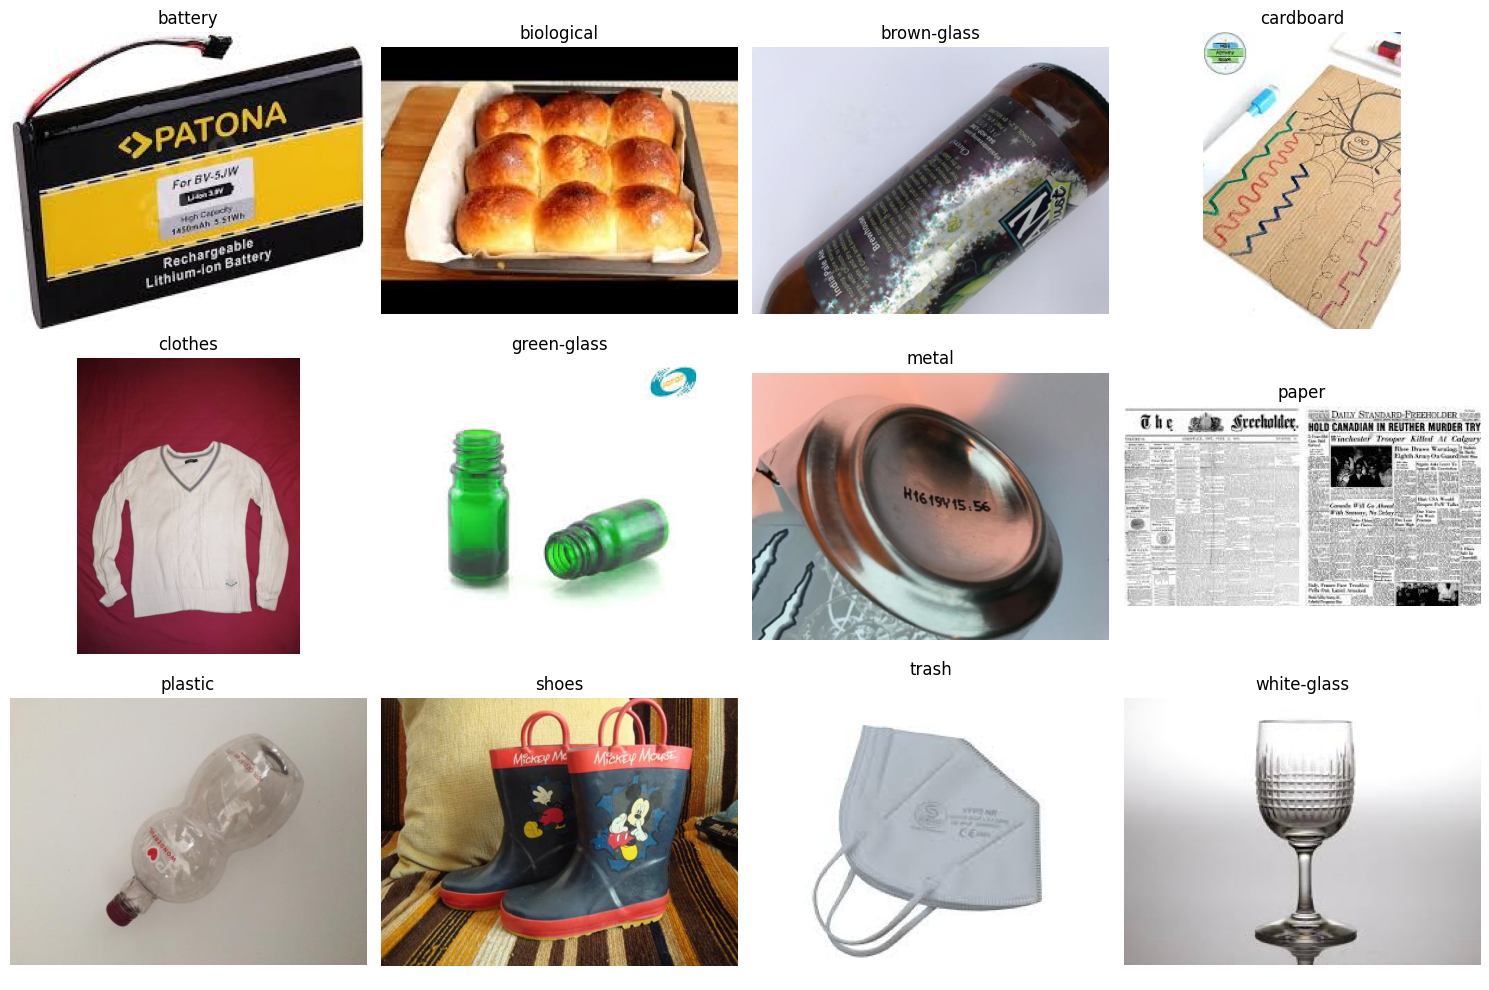

In [35]:
import random
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(15,10))

for i, cls in enumerate(class_names):
    class_path = os.path.join(dataset_path, cls)

    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(3,4,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

Data Preprocessing

Define Parameters

In [36]:
BATCH_SIZE = 32
IMG_HEIGHT = 180
IMG_WIDTH = 180
SEED = 123

Create Training Datasets

In [37]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

Found 15515 files belonging to 12 classes.
Using 12412 files for training.


Create Validation Datasets

In [38]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

Found 15515 files belonging to 12 classes.
Using 3103 files for validation.


Store Class Names

In [39]:
class_names = train_dataset.class_names

print(class_names)

['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


Training Images

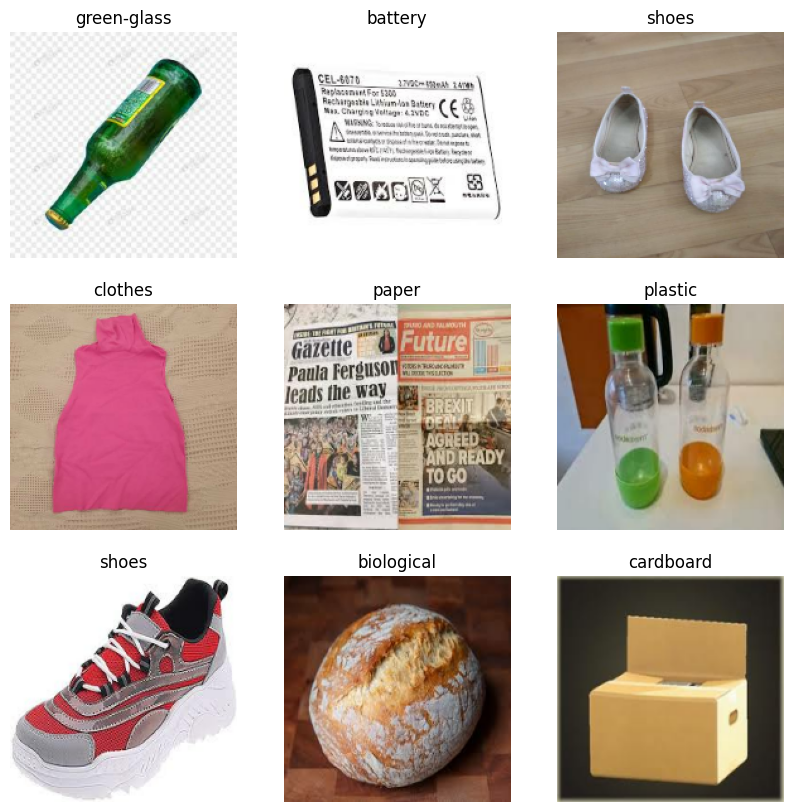

In [40]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

Optimize Dataset

In [41]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    train_dataset
    .cache()
    .shuffle(1000)
    .prefetch(AUTOTUNE)
)

validation_dataset = (
    validation_dataset
    .cache()
    .prefetch(AUTOTUNE)
)

Build CNN Model

In [42]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(180,180,3)),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(12, activation='softmax')

])

In [43]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,648,524 (25.36 MB)

 Trainable params: 6,648,524 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

Compile the CNN Model

In [44]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train the CNN Model

In [45]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

EPOCHS = 25

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/25
388/388 ━━━━━━━━━━━━━━━━━━━━ 36s 52ms/step - accuracy: 0.3497 - loss: 6.0583 - val_accuracy: 0.4051 - val_loss: 1.8639
Epoch 2/25
388/388 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.3829 - loss: 1.9391 - val_accuracy: 0.4080 - val_loss: 1.8814
Epoch 3/25
388/388 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.4239 - loss: 1.7874 - val_accuracy: 0.4396 - val_loss: 1.6544
Epoch 4/25
388/388 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.4782 - loss: 1.5908 - val_accuracy: 0.4889 - val_loss: 1.5889
Epoch 5/25
388/388 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.5388 - loss: 1.4000 - val_accuracy: 0.5495 - val_loss: 1.4436
Epoch 6/25
388/388 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.5985 - loss: 1.2208 - val_accuracy: 0.5517 - val_loss: 1.4431
Epoch 7/25
388/388 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.6432 - loss: 1.0910 - val_accuracy: 0.5840 - val_loss: 1.3790
Epoch 8/25
388/388 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.6891 - loss: 0.9607 - 

Accuracy and Loss Plot

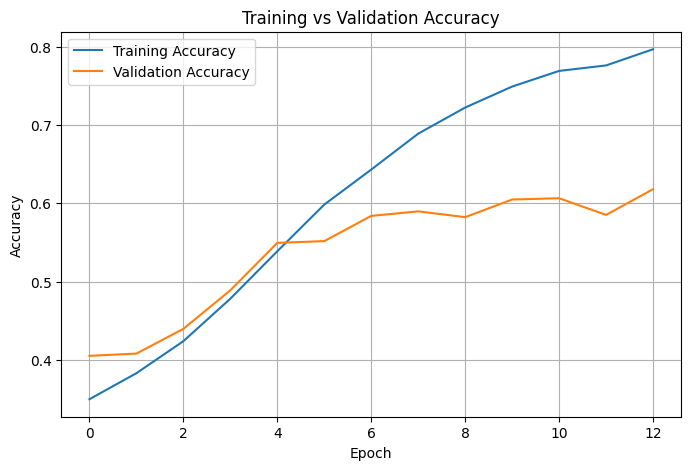

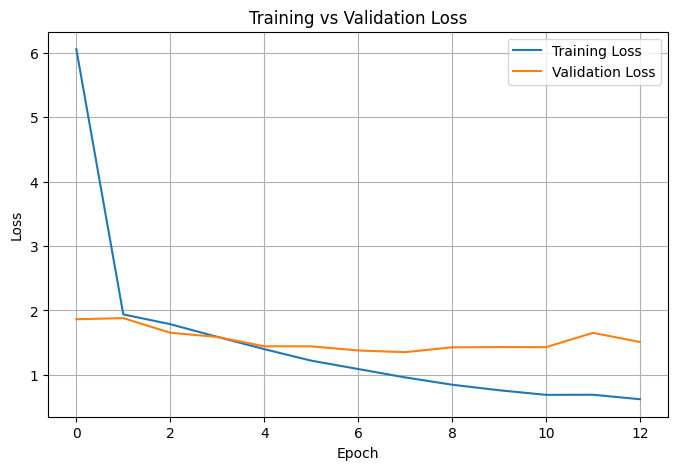

In [46]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Model Performance

The CNN achieved a training accuracy of approximately 79.7% and a validation accuracy of 61.8%. The difference between training and validation accuracy indicates some overfitting, which could be reduced in future work using transfer learning, stronger data augmentation, or additional training data.

Model Evaluation

In [47]:
loss, accuracy = model.evaluate(validation_dataset)

print(f"\nValidation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy*100:.2f}%")

97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5898 - loss: 1.3528

Validation Loss: 1.3528
Validation Accuracy: 58.98%


Classification Report

In [48]:
import numpy as np
from sklearn.metrics import classification_report

y_true = np.concatenate([y for x, y in validation_dataset], axis=0)

y_pred = model.predict(validation_dataset, verbose=0)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

     battery       0.49      0.44      0.46       187
  biological       0.57      0.47      0.52       200
 brown-glass       0.68      0.56      0.61       133
   cardboard       0.36      0.46      0.40       178
     clothes       0.75      0.91      0.82      1070
 green-glass       0.81      0.84      0.83       115
       metal       0.32      0.08      0.12       168
       paper       0.47      0.30      0.37       198
     plastic       0.30      0.14      0.19       184
       shoes       0.49      0.57      0.53       391
       trash       0.34      0.57      0.43       136
 white-glass       0.41      0.22      0.28       143

    accuracy                           0.59      3103
   macro avg       0.50      0.46      0.46      3103
weighted avg       0.56      0.59      0.56      3103



Confusion Matrix

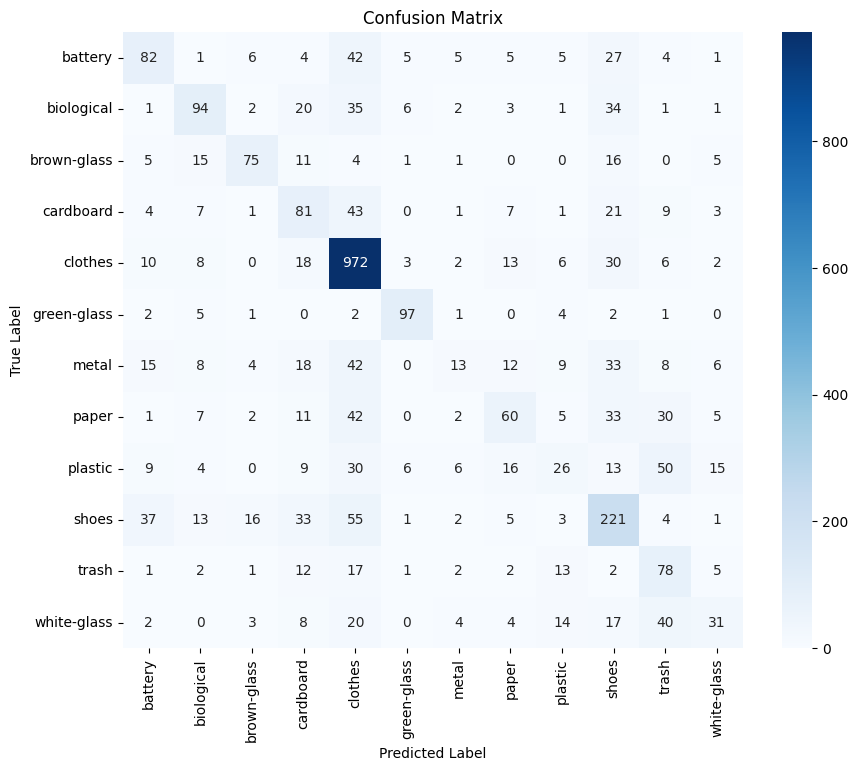

In [49]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Save the Trained Model

In [51]:
model.save("/content/drive/MyDrive/Entri Assignments/Final Project_Garbage Classification/garbage_classifier.keras")

print("New model saved successfully!")

New model saved successfully!


In [52]:
import json

with open("/content/drive/MyDrive/Entri Assignments/Final Project_Garbage Classification/class_names.json", "w") as f:
    json.dump(class_names, f)

print("Class names saved successfully!")

Class names saved successfully!


In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
import os

project_path = "/content/drive/MyDrive/Entri Assignments/Final Project_Garbage Classification"

print(os.listdir(project_path))

['kaggle.json', '.ipynb_checkpoints', 'dataset', 'garbage_classifier_v1.keras', 'class_names.json', 'Garbage Classification using CNN.ipynb', 'garbage_classifier.keras']


In [55]:
import tensorflow as tf

model2 = tf.keras.models.load_model(
    "/content/drive/MyDrive/Entri Assignments/Final Project_Garbage Classification/garbage_classifier.keras"
)

print("Model loaded successfully!")

model2.summary()

Model loaded successfully!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,945,574 (76.09 MB)

 Trainable params: 6,648,524 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,297,050 (50.72 MB)

In [56]:
batch = next(iter(validation_dataset))

images, labels = batch

pred = model2.predict(images[:1])

print(pred.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 747ms/step
(1, 12)


In [57]:
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

print(model.input_shape)
print(model.output_shape)

TensorFlow: 2.20.0
Keras: 3.13.2
(None, 180, 180, 3)
(None, 12)


In [58]:
import tensorflow as tf

loaded_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Entri Assignments/Final Project_Garbage Classification/garbage_classifier.keras"
)

print("✅ Model loaded successfully")
loaded_model.summary()

✅ Model loaded successfully


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,945,574 (76.09 MB)

 Trainable params: 6,648,524 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,297,050 (50.72 MB)

In [59]:
batch = next(iter(validation_dataset))

images, labels = batch

pred = loaded_model.predict(images[:1])

print(pred.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
(1, 12)


Test Saved Model

In [60]:
from tensorflow.keras.models import load_model

loaded_model = load_model(
    "/content/drive/MyDrive/Entri Assignments/Final Project_Garbage Classification/garbage_classifier.keras"
)

print("Model loaded successfully!")

Model loaded successfully!


Predict Image from Dataset

In [61]:
print(type(loaded_model))
print(class_names)

<class 'keras.src.models.sequential.Sequential'>
['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


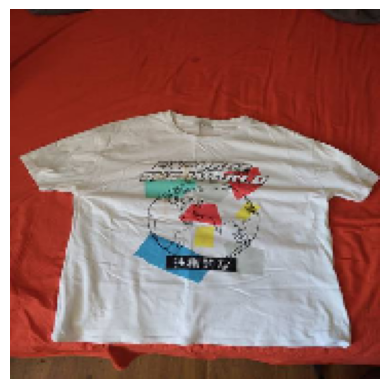

Predicted Class : clothes
Confidence      : 100.00%


In [62]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

img_path = "/content/drive/MyDrive/Entri Assignments/Final Project_Garbage Classification/dataset/garbage_classification/clothes/clothes1.jpg"

img = image.load_img(img_path, target_size=(180,180))
plt.imshow(img)
plt.axis("off")
plt.show()

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = loaded_model.predict(img_array, verbose=0)

predicted_index = np.argmax(prediction)
confidence = np.max(prediction) * 100

print("Predicted Class :", class_names[predicted_index])
print(f"Confidence      : {confidence:.2f}%")

In [63]:
prediction = loaded_model.predict(img_array, verbose=0)[0]

top5 = np.argsort(prediction)[::-1][:5]

print("Top 5 Predictions:")
for i in top5:
    print(f"{class_names[i]:15s} : {prediction[i]*100:.2f}%")

Top 5 Predictions:
clothes         : 100.00%
paper           : 0.00%
cardboard       : 0.00%
shoes           : 0.00%
metal           : 0.00%
